#### 로지스틱 회귀로 와인 분류하기

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
wine = pd.read_csv("../Data/wine.csv")
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [5]:
wine['class'].unique()

array([0., 1.])

> 0 : Red wine, 1 : White wine

In [6]:
wine.shape

(6497, 4)

### Feature 와 Target

In [7]:
data = wine.iloc[:,:3].to_numpy()
target = wine['class'].to_numpy()

### Train과 Test

In [8]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
  train_test_split(
    data,
    target,
    random_state=42,
    test_size=0.2
  )

### 표준화 하기(로지스틱 회귀 이므로)



In [9]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

### 로지스틱 회귀 모델

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print("Train :", lr.score(train_scaled, train_target))
print("Test  :", lr.score(test_scaled, test_target))

Train : 0.7808350971714451
Test  : 0.7776923076923077


In [ ]:
# 가중치와 편차
print(lr.coef_, lr.intercept_)
# PH가 - 값이다. 말이 안된다.

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


---
### 결정트리(Decision Tree)

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input,train_target)

print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.996921300750433
Test  : 0.8584615384615385


#### 시각화

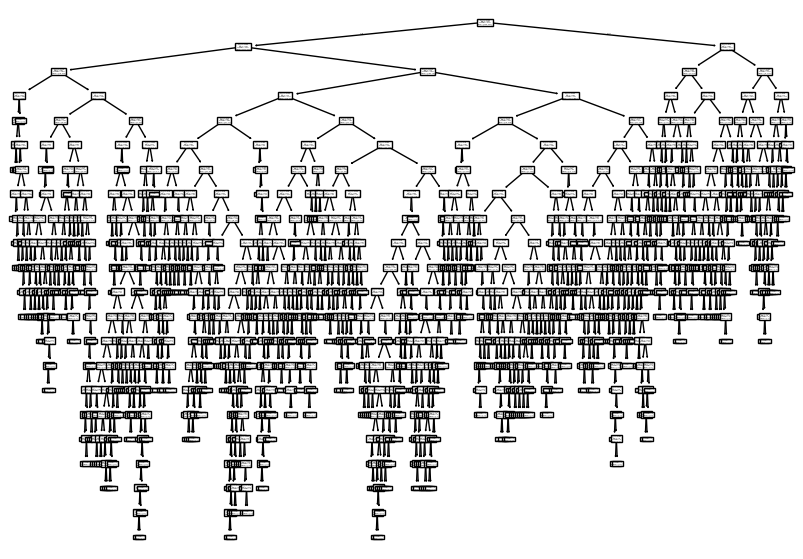

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

> 맨 위의 단계를 root node라고 하고 맨 마지막 단계는 leaf node라고 한다.   
시간이 너무 많이 걸리고 단계가 복잡하다.

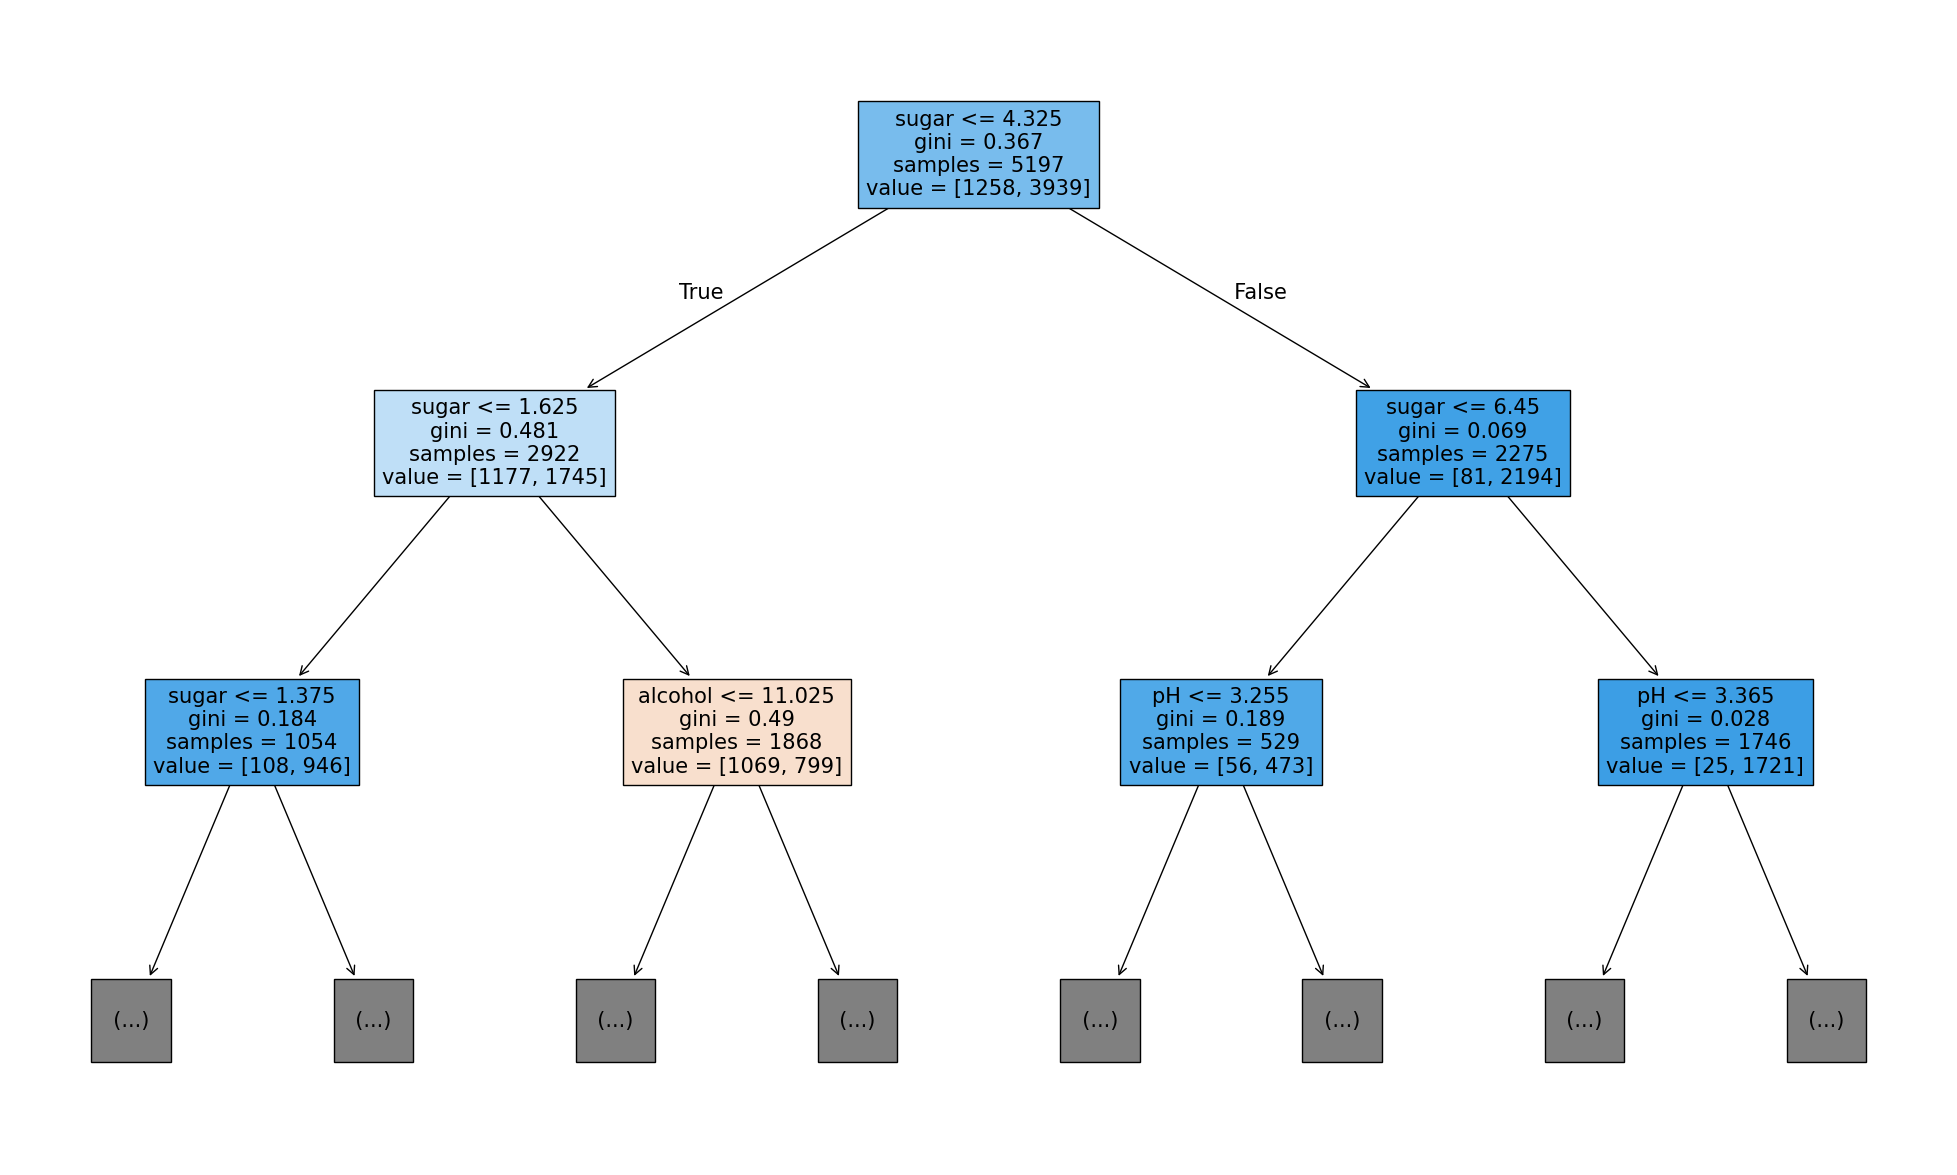

In [21]:
# decision tree의 단계(depth)를 단순하게 하자

plt.figure(figsize=(25,15))
plot_tree(dt, max_depth=2, filled=True, feature_names=['alcohol','sugar','pH'])
plt.show()

> 양성 일수록 파란색으로 표시된다.   
루트 노드에서 sugar <= 4.325 이면 왼쪽으로 이동하고 아니면 오른쪽 이동한다.   
루트 노드에서 총 샘플수는 5197개 인데 true는 2922개이고 false는 2275개 이다.   
루트노드에서 value는 해당 노드의 음성과 양성 클래스(red, white)의 갯수이다.   


### 지니 불순도(Geni Impurity)
지니불순도 = 1 - (음성클래스비율^2 + 양성클래스비율^2).   
위와 같이 지니 불순도가 0이 나올 때를 순수 노드라고 한다.
leaf node가 순수노드 인것은 좋으나 과대적합이 발생한다.

따라서 max_deapth를 찾는것이 중요하다.

### 가지치기(Tree Pruning)
- max_depth의 parameter값을 조절한다.
- Decision Tree의 과대 적합을 막는다.
- 선형회귀식 처럼 L1규제, L2규제 등을 사용할 수 없다.

In [23]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input,train_target)

print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.8454877814123533
Test  : 0.8415384615384616


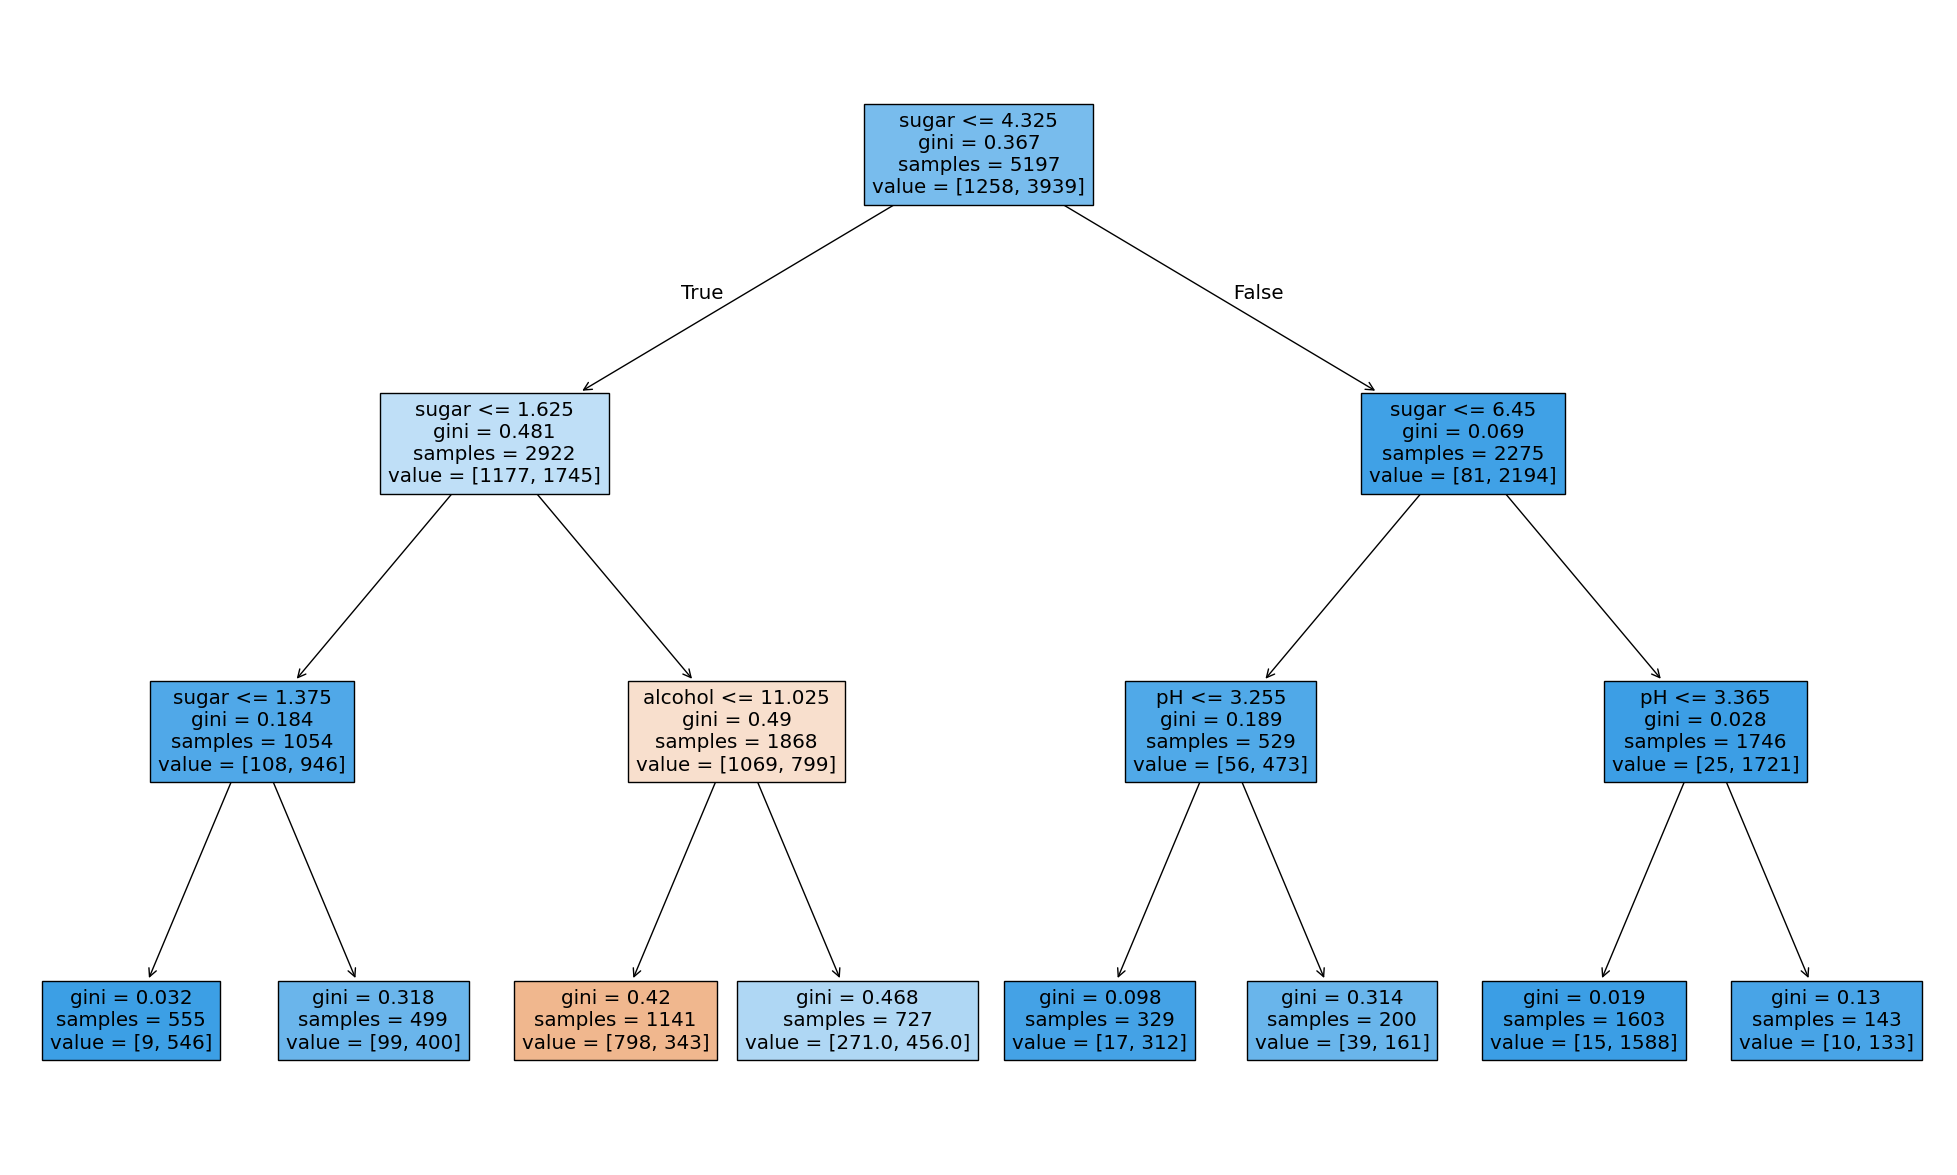

In [24]:
plt.figure(figsize=(25,15))
plot_tree(dt, max_depth=3, filled=True, feature_names=['alcohol','sugar','pH'])
plt.show()

> red wine(노란색)은 하나만 성립 되었고 나머지는 모두 white wine(파란색)이고 진한 파란색 일수록 white wine에 정확하다.

In [25]:
# 특성 중요도
dt.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

---
### 최적화

In [28]:
dt = DecisionTreeClassifier(min_impurity_decrease=0.0005,random_state=42) # 노드를 분할하는 기준인 지니 불순도의 최소값이 0.05%
dt.fit(train_input,train_target)

print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.8874350586877044
Test  : 0.8615384615384616


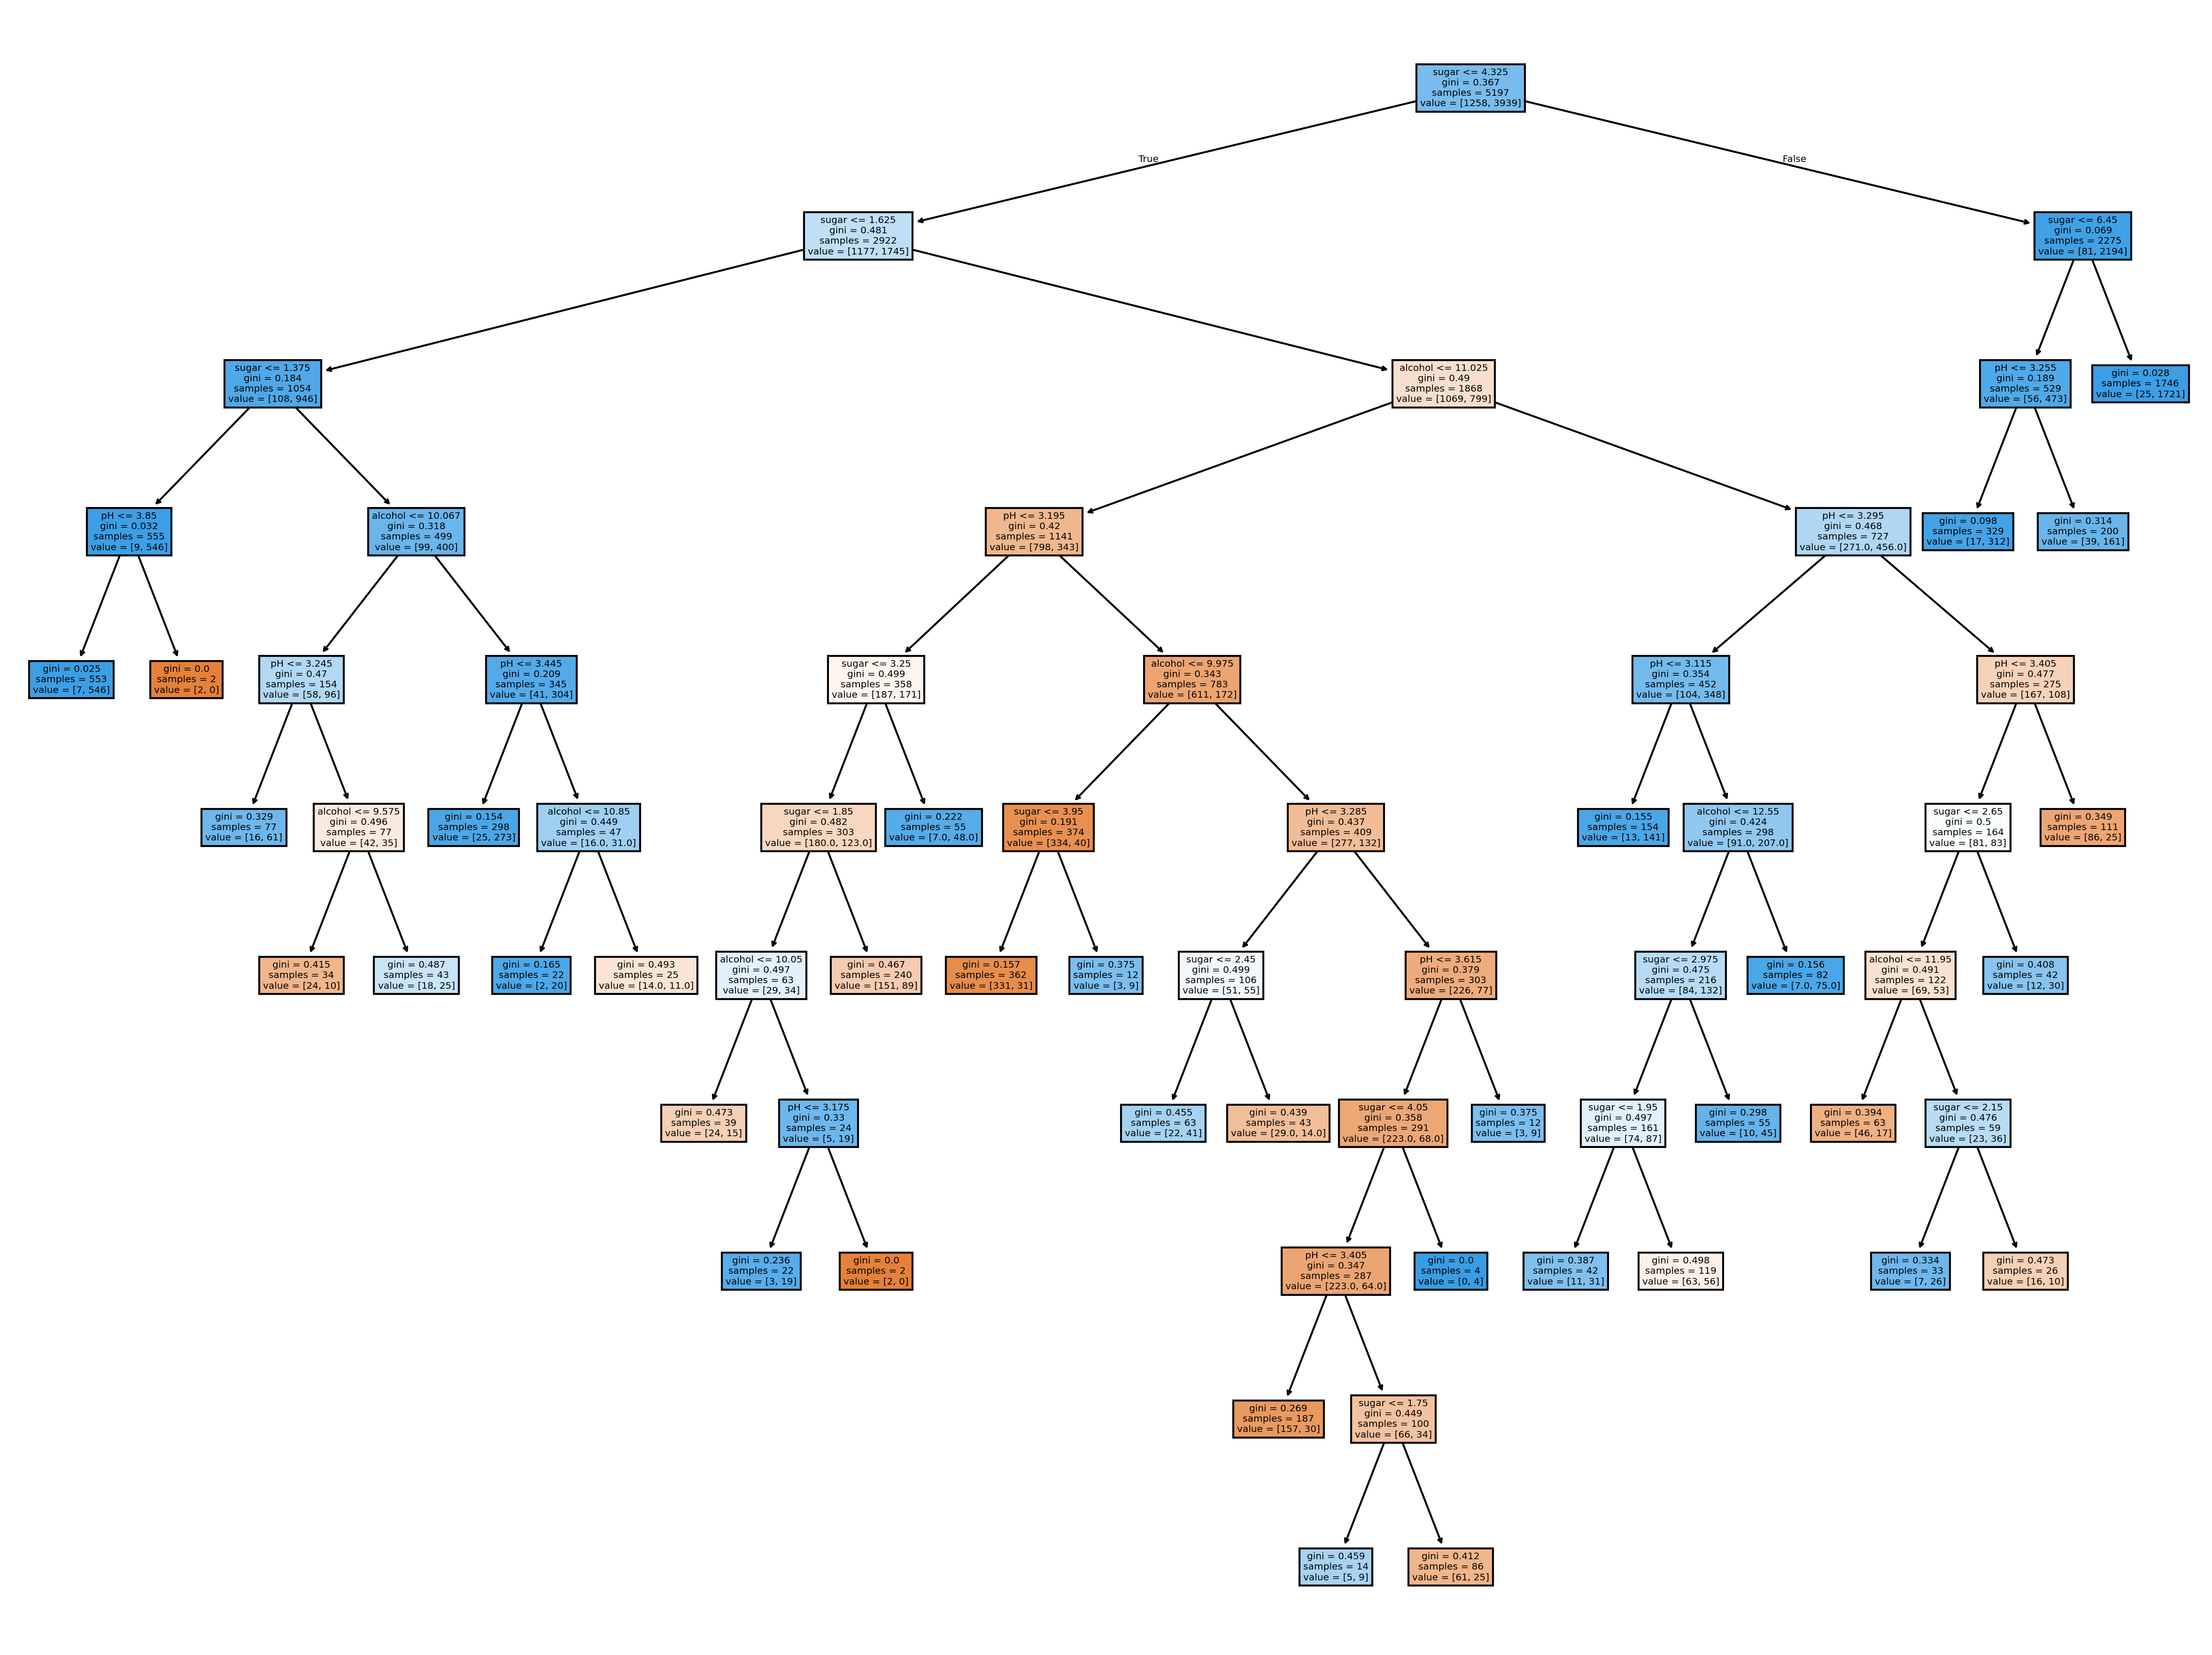

In [31]:
plt.figure(figsize=(20,15), dpi=300)
plot_tree(dt, filled=True, feature_names=['alcohol','sugar','pH'])
plt.savefig("../Data/wine.jpg")
plt.show()